In [473]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [474]:
df = pd.read_csv('../car_fuel_efficiency_2026.csv')

In [475]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


Preparing the dataset

In [476]:
df_base = df[["engine_displacement", "horsepower", "vehicle_weight", "model_year", "fuel_efficiency_mpg"]]

In [477]:
df_base.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


In [478]:
df_base.shape

(10000, 5)

EDA

<Axes: >

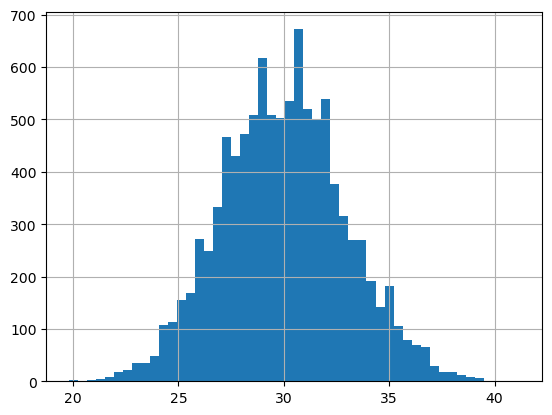

In [479]:
df_base.fuel_efficiency_mpg.hist(bins=50)

Answer = the efficiency column doesn't have a long tail

In [480]:
df_base.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

Question 1


The horsepower column has 877 missing values

Question 2

In [481]:
df_base["horsepower"].median()

np.float64(254.0)

Median = 254

Question 3

In [482]:
n = len(df_base)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df_base.iloc[idx[:n_train]]
df_val = df_base.iloc[idx[n_train:n_train + n_val]]
df_test = df_base.iloc[idx[n_train + n_val:]]



In [483]:
df_train.isnull().sum()

engine_displacement      0
horsepower             538
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [484]:
df_train_mean = df_train.fillna(df_train.mean())
df_val_mean = df_val.fillna(df_train.mean())
df_test_mean = df_test.fillna(df_train.mean())

In [485]:
df_train_mean.isnull().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
fuel_efficiency_mpg    0
dtype: int64

In [486]:
df_train_zero = df_train.fillna(0)
df_val_zero = df_val.fillna(0)
df_test_zero = df_test.fillna(0)

In [487]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

In [488]:
del df_train_mean["fuel_efficiency_mpg"]
del df_val_mean["fuel_efficiency_mpg"]
del df_test_mean["fuel_efficiency_mpg"]

del df_train_zero["fuel_efficiency_mpg"]
del df_val_zero["fuel_efficiency_mpg"]
del df_test_zero["fuel_efficiency_mpg"]

In [489]:
df_train_mean.head()

,engine_displacement,horsepower,vehicle_weight,model_year
6252,1900,239.000000,3790,2015
4684,2000,224.000000,4380,1992
1731,2330,286.000000,4090,2022
4742,2300,254.463383,4150,1997
4521,2340,269.000000,4400,2001


In [490]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

In [491]:
w_0_mean, w_mean = train_linear_regression(df_train_mean, y_train)
y_pred_mean = w_0_mean + df_val_mean.dot(w_mean)
y_pred_mean

2480    31.542884
289     29.925051
6086    31.564595
3075    29.954618
8123    31.001714
          ...    
1638    33.091012
5891    27.179325
7427    30.544083
608     30.857012
6907    31.553137
Length: 2000, dtype: float64

In [492]:
w_0_zero, w_zero = train_linear_regression(df_train_zero, y_train)
y_pred_zero = w_0_zero + df_val_zero.dot(w_zero)
y_pred_zero

2480    31.645021
289     29.865730
6086    31.588389
3075    30.025841
8123    31.006497
          ...    
1638    33.080327
5891    27.051882
7427    30.531333
608     30.750851
6907    31.629128
Length: 2000, dtype: float64

In [493]:
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

In [494]:
rmse(y_val, y_pred_mean).round(3)

np.float64(2.202)

In [495]:
rmse(y_val, y_pred_zero).round(3)

np.float64(2.205)

The fillna with mean gives a better RMSE = 2.202

Question 4

In [496]:
df_train_zero.isnull().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
dtype: int64

In [497]:
def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg

    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

In [498]:
for r in [0, 0.001, 0.01, 0.1, 1, 10]:
    w_0, w = train_linear_regression_reg(df_train_zero, y_train, r=r)
    y_pred = w_0 + df_val_zero.dot(w)
    root = rmse(y_val, y_pred).round(3)
    print('%5s, %.5f, %.5f, %.5f, %.5f, %.5f, %.4f' % (r, w_0, w[0], w[1], w[2], w[3], root))


    0, -153.88496, -0.00152, -0.00000, -0.00395, 0.10215, 2.2050
0.001, -153.30859, -0.00152, 0.00001, -0.00396, 0.10186, 2.2050
 0.01, -148.30921, -0.00154, 0.00017, -0.00397, 0.09940, 2.2060
  0.1, -111.83871, -0.00172, 0.00133, -0.00406, 0.08141, 2.2240
    1, -32.33187, -0.00210, 0.00387, -0.00425, 0.04219, 2.3490
   10, -3.98712, -0.00223, 0.00477, -0.00431, 0.02821, 2.4190


r = 0 gives teh best RMSE

Question 5

In [499]:
n = len(df_base)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

def random_split(df):

    seed_res = {}

    for seed in np.arange(10):
        np.random.seed(seed)
        idx = np.arange(n)
        np.random.shuffle(idx)
        seed_res[seed] = idx

    return seed_res


df_seed_list = {}

for seed, idx in random_split(df_base).items():    

    df_train = pd.DataFrame()
    df_val = pd.DataFrame()
    df_test = pd.DataFrame()

    df_train = df_base.iloc[idx[:n_train]]
    df_val = df_base.iloc[idx[n_train:n_train + n_val]]
    df_test = df_base.iloc[idx[n_train + n_val:]]

    df_seed_list[seed] = (df_train, df_val, df_test)  




In [260]:
for seed in df_seed_list.keys():
    df_train, df_val, df_test = df_seed_list[seed]

    df_train = df_train.fillna(0, inplace = True)
    df_val= df_val.fillna(0, inplace = True)
    df_test = df_test.fillna(0, inplace = True)



In [261]:
rmse_dict = {}

for seed in df_seed_list.keys():
    df_train, df_val, df_test = df_seed_list[seed]
    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    y_test = df_test.fuel_efficiency_mpg.values

    del df_train["fuel_efficiency_mpg"]
    del df_val["fuel_efficiency_mpg"]
    del df_test["fuel_efficiency_mpg"]

    w_0, w = train_linear_regression(df_train, y_train)
    y_pred = w_0 + df_val.dot(w)
    root = rmse(y_val, y_pred).round(3)

    rmse_dict[seed] = root
    
    print ('Seed: %d, RMSE: %.4f' % (seed, root))


Seed: 0, RMSE: 2.2390
Seed: 1, RMSE: 2.2020
Seed: 2, RMSE: 2.1630
Seed: 3, RMSE: 2.2040
Seed: 4, RMSE: 2.2020
Seed: 5, RMSE: 2.2460
Seed: 6, RMSE: 2.2700
Seed: 7, RMSE: 2.1910
Seed: 8, RMSE: 2.2170
Seed: 9, RMSE: 2.2070


In [262]:
np.std(list(rmse_dict.values())).round(3)

np.float64(0.029)

The STD of the RMSE is 0.029

Question 6

In [293]:
df_seed_list[9]

(      engine_displacement  horsepower  vehicle_weight  model_year
 3644                 2320       246.0            4100        2014
 9184                 2230       252.0            4250        1998
 520                  2700       276.0            4490        2008
 5685                 2220       269.0            4060        2004
 2401                 2370         0.0            4690        1979
 ...                   ...         ...             ...         ...
 7911                 1950       231.0            4150        1989
 251                  2060       249.0            3910        2012
 2298                 2180       223.0            4360        2014
 1741                 2420       248.0            4080        1977
 7606                 2040       245.0            4420        2018
 
 [6000 rows x 4 columns],
       engine_displacement  horsepower  vehicle_weight  model_year
 9983                 2410       278.0            4370        2017
 8469                 2260       2

In [500]:
#this code will run only if the cells are executed before the fuel_efficiency_mpg column is deleted from the dataframes in the df_seed_list dictionary.

df_train_9, df_val_9, df_test_9 = df_seed_list[9]

y_train_9 = df_train_9.fuel_efficiency_mpg.values
y_val_9 = df_val_9.fuel_efficiency_mpg.values
y_test_9 = df_test_9.fuel_efficiency_mpg.values

del df_train_9["fuel_efficiency_mpg"]
del df_val_9["fuel_efficiency_mpg"]
del df_test_9["fuel_efficiency_mpg"]

y_train_val_fuse_9 = np.concatenate([y_train_9, y_val_9])
df_train_val_fuse_9 = pd.concat([df_train_9, df_val_9], axis=0)



In [501]:
df_train_val_fuse_9.fillna(0, inplace = True)

,engine_displacement,horsepower,vehicle_weight,model_year
3644,2320,246.0,4100,2014
9184,2230,252.0,4250,1998
520,2700,276.0,4490,2008
5685,2220,269.0,4060,2004
2401,2370,0.0,4690,1979
...,...,...,...,...
8981,2690,324.0,4510,2023
3978,1920,190.0,4000,1998
6198,1800,225.0,3980,1994
1102,1970,232.0,3560,2009


In [502]:
w0, w = train_linear_regression_reg(df_train_val_fuse_9, y_train_val_fuse_9, r=0.001)

In [503]:
w0, w

(np.float64(-152.37535772516975),
 array([-0.00135534, -0.00042645, -0.00401765,  0.10140402]))

In [504]:
rmse(y_test_9, w0 + df_test_9.dot(w)).round(3)

np.float64(2.239)

The RMSE on the test data set using seed=9 is 2.239